In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf

I0000 00:00:1779225386.423615  335061 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779225386.424248  335061 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779225386.460619  335061 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779225387.707818  335061 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [10]:
df = pd.read_csv('../data/spam.csv', delimiter=',', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [15]:
df.drop(df.columns[[2, 3, 4]], axis=1, inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Text(0.5, 1.0, 'Number of ham and spam messages')

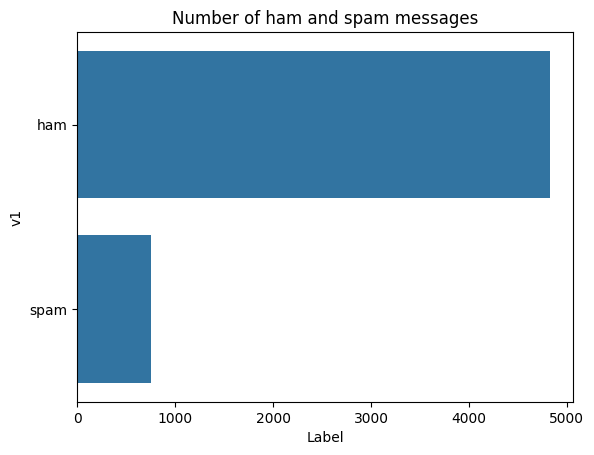

In [24]:
sns.countplot(df.v1)
plt.xlabel('Label')
plt.title('Number of ham and spam messages')

In [27]:
X = df.v2
Y = df.v1
le = LabelEncoder()
Y = le.fit_transform(Y)
Y = Y.reshape(-1, 1)

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15)

In [33]:
X_train

4165    Well if I'm that desperate I'll just call arma...
1690    Sunshine Quiz Wkly Q! Win a top Sony DVD playe...
2824    Congratulations - Thanks to a good friend U ha...
2662    Hello darling how are you today? I would love ...
3178    Does cinema plus drink appeal tomo? * Is a fr ...
                              ...                        
3247            Also track down any lighters you can find
3949    I got to video tape pple type in message lor. ...
300     Awesome, I remember the last time we got someb...
5011    U attend ur driving lesson how many times a wk...
1983    I wnt to buy a BMW car urgently..its vry urgen...
Name: v2, Length: 4736, dtype: str

In [38]:
max_words = 1000
max_len = 150
tok = tf.keras.preprocessing.text.Tokenizer(num_words=max_words)
tok.fit_on_texts(X_train)
sequences = tok.texts_to_sequences(X_train)
sequences_matrix = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_len)

In [ ]:
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

wandb.init(
    project="dnn_lab5",
    config={
        "max_len": 150,
        "max_words": 1000,
        "embedding_dim": 50,
        "lstm_units": 64,
        "dense_units": 256,
        "dropout_rate": 0.5,
        "batch_size": 128,
        "epochs": 10,
        "optimizer": "rmsprop",
        "loss": "binary_crossentropy",
    }
)

cfg = wandb.config

In [53]:
class RNN(tf.keras.Model):
    def __init__(
        self,
        max_len: int = cfg.max_len,
        max_words: int = cfg.max_words,
        embedding_dim: int = cfg.embedding_dim,
        lstm_units: int = cfg.lstm_units,
        dense_units: int = cfg.dense_units,
        dropout_rate: float = cfg.dropout_rate,
        **kwargs,
    ):
        super(RNN, self).__init__(**kwargs)

        self.max_len = max_len
        self.max_words = max_words
        self.embedding_dim = embedding_dim
        self.lstm_units = lstm_units
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate

        self.network = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(max_len,), name="inputs"),
            tf.keras.layers.Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, name="embedding"),
            tf.keras.layers.LSTM(units=lstm_units, name="lstm"),
            tf.keras.layers.Dense(units=dense_units, name="fc1"),
            tf.keras.layers.Activation("relu", name="relu"),
            tf.keras.layers.Dropout(rate=dropout_rate, name="dropout"),
            tf.keras.layers.Dense(units=1, name="output"),
            tf.keras.layers.Activation("sigmoid", name="sigmoid"),
        ], name="rnn_sequential")

    def call(self, x):
        return self.network(x)

    def get_config(self):
        config = super(RNN, self).get_config()
        config.update({
            "max_len": self.max_len,
            "max_words": self.max_words,
            "embedding_dim": self.embedding_dim,
            "lstm_units": self.lstm_units,
            "dense_units": self.dense_units,
            "dropout_rate": self.dropout_rate,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [54]:
model = RNN()
model.compile(
    loss=cfg.loss,
    optimizer=tf.keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)
model.network.summary()

/home/rybkin/Projects/study/dln/2_labs/my/lab5/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "rnn_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 50)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu (Activation)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid (Activation)            │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,337 (376.32 KB)

 Trainable params: 96,337 (376.32 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
import os
os.makedirs("../models/checkpoints", exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=0.0001,
        patience=3,
        restore_best_weights=True,
    ),
    WandbMetricsLogger(log_freq="epoch"),        # logs loss/accuracy to wandb
    WandbModelCheckpoint(                         # saves best checkpoint to wandb
        filepath="../models/checkpoints/rnn_{epoch:02d}.keras",
        monitor="val_loss"
    ),
]

In [64]:
model.fit(
    sequences_matrix,
    Y_train,
    batch_size=cfg.batch_size,
    epochs=cfg.epochs,
    validation_split=0.2,
    callbacks=callbacks,
)

Epoch 1/10


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9963 - loss: 0.0137 - val_accuracy: 0.9810 - val_loss: 0.0845
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9971 - loss: 0.0118 - val_accuracy: 0.9821 - val_loss: 0.0769
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9982 - loss: 0.0090 - val_accuracy: 0.9810 - val_loss: 0.0928
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9982 - loss: 0.0079 - val_accuracy: 0.9810 - val_loss: 0.0879
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9979 - loss: 0.0078 - val_accuracy: 0.9810 - val_loss: 0.0899


In [66]:
test_sequences = tok.texts_to_sequences(X_test)
test_sequences_matrix = tf.keras.preprocessing.sequence.pad_sequences(test_sequences,maxlen=max_len)

In [68]:
accr = model.evaluate(test_sequences_matrix,Y_test)
print('Test set\n Loss: {:0.3f}\n Accuracy: {:0.3f}'.format(accr[0],accr[1]))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9797 - loss: 0.0579
Test set
 Loss: 0.058
 Accuracy: 0.980
